#  Reconocimiento de dígitos con Redes Neuronales
### Challenge Cyberdyne Systems · Parte 1: MNIST

**Objetivo:** entrenar una red neuronal que reconozca dígitos escritos a mano (0–9) y entender *por qué* funciona: comparamos funciones de activación (**ReLU vs Sigmoid**) y optimizadores (**SGD vs Adam**).

**Framework elegido: TensorFlow / Keras.** Lo elegí porque:
- Con `Sequential` la red se arma apilando capas, en pocas líneas y fácil de leer.
- `fit()` devuelve un `history` con el loss y la accuracy de cada época, ideal para graficar sin código extra.
- MNIST y Fashion MNIST vienen incluidos en `tf.keras.datasets`, ya divididos en train y test.
- Analogía: Keras es un auto automático (llegás igual, con menos esfuerzo) y PyTorch es uno manual (más control, más código). Para una red de 2 capas no necesitamos ese control extra.

**Contenido:** 1. Carga y exploración · 2. Preprocesamiento · 3. Arquitectura · 4. Experimentos · 5. Evaluación · 6. Conclusiones

---
## 1. Carga y exploración del dataset

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Pixel mínimo: 0
Pixel máximo: 255
Imágenes por dígito: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


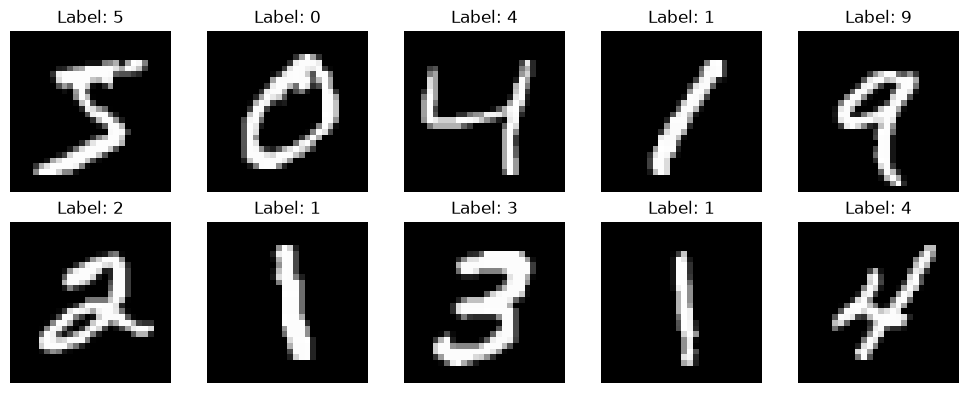

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# MNIST por defecto ya viene dividido en train y test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Pixel mínimo:", X_train.min())
print("Pixel máximo:", X_train.max())

# Cuántas imágenes hay de cada dígito (para ver si el dataset está balanceado)
print("Imágenes por dígito:", np.bincount(y_train))

# Ejemplos visuales: las primeras 10 imágenes de entrenamiento
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

**Qué tenemos:** 60.000 imágenes para entrenar y 10.000 para probar. Cada imagen es de **28×28 píxeles** en escala de grises (0 = negro, 255 = blanco) y su etiqueta es el dígito que representa (0–9).

**Balance de clases:** hay entre ~5.400 y ~6.700 imágenes de cada dígito (ver `Imágenes por dígito`), es decir, el dataset está bastante balanceado. Por eso la *accuracy* es una métrica justa: el modelo no puede "hacer trampa" prediciendo siempre el dígito más común.

**Qué esperar:** los dígitos con trazos parecidos (4 y 9, 3 y 5, 7 y 1) van a ser los más difíciles de separar.

---

## 2. Preprocesamiento

Dos cosas dejan los datos listos para entrenar:
- **Normalizar (÷ 255):** pasamos los píxeles de 0–255 a 0–1. Es como pasar de "puntos sobre 255" a un porcentaje: con números chicos el entrenamiento es más estable y rápido.
- **Reshape (28×28 → 784):** cada imagen se aplana a una lista de 784 valores. Lo hace la capa `Flatten` dentro del propio modelo, por eso no hay una celda de reshape aparte.

**División de los datos:** los 60.000 de train se parten con `validation_split=0.2` → 48.000 para entrenar y 12.000 para validar. Los 10.000 de test **no se tocan** hasta la evaluación final

In [2]:
#Normalizamos los pixeles para trabajar en una escala más controlada
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 1.0


___

## 3. Arquitectura

**Estructura:** `Entrada (28×28) → Flatten (784) → Dense 128 → Dense 10 (softmax)`

### Entrada
Usamos **Flatten** porque cada imagen es una matriz de 28 filas × 28 columnas y las capas Dense trabajan con listas de valores: la capa "desenrolla" la matriz en 784 números.

### Primera capa (oculta)
128 neuronas con función de activación. Usamos **1** capa, la opción más simple que alcanza para este problema. 128 es un punto de partida razonable: ni tan chico que no pueda aprender, ni tan grande que memorice.

### Segunda capa (salida)
10 neuronas, una por dígito, con **softmax**: convierte las 10 salidas en probabilidades que suman 1. El dígito predicho es el de mayor probabilidad.

**Parámetros:** 784×128 + 128 = 100.480 en la capa oculta y 128×10 + 10 = 1.290 en la salida → **101.770** en total.

In [4]:
#Estructura de la RED
tf.keras.utils.set_random_seed(42)  # semilla: mismos pesos iniciales en cada ejecución
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    #Capa de activación
    tf.keras.layers.Dense(128, activation="relu"),
    #Capa calculo de probabilidad de la predicción
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Aprendizaje del modelo
- Aqui definimos el optimizador a ser usado. Para corregir los pesos.
- Como calcular el loss.
- Mostrar métricas de imagenes clasificadas correctamente.

In [5]:
model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento base
Este primer entrenamiento (**ReLU + SGD**) es nuestro **modelo base**, el punto de comparación.
- `epochs=10`: repite el dataset de entrenamiento 10 veces (una pasada completa = 1 época).
- `batch_size=32`: por cada paso analiza 32 imágenes y recién ahí corrige los pesos.
- `validation_split=0.2`: apartamos el 20% del entrenamiento para validar mientras desarrollamos el modelo y tomar decisiones.

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.8263 - loss: 0.7001 - val_accuracy: 0.9013 - val_loss: 0.3729
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.9016 - loss: 0.3572 - val_accuracy: 0.9159 - val_loss: 0.3055
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - accuracy: 0.9148 - loss: 0.3057 - val_accuracy: 0.9246 - val_loss: 0.2738
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - accuracy: 0.9230 - loss: 0.2751 - val_accuracy: 0.9293 - val_loss: 0.2521
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.9296 - loss: 0.2525 - val_accuracy: 0.9337 - val_loss: 0.2352
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - accuracy: 0.9348 - loss: 0.2342 - val_accuracy: 0.9380 - val_loss: 0.2212
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - accuracy: 0.9392 - loss: 0.2187 - val_accuracy: 0.9420 - val_loss: 0.2093
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.9430 -

Con ReLU + SGD el modelo base llega a ~95% de accuracy de validación en 10 épocas y **sigue mejorando en cada una**: todavía no terminó de aprender. Es un buen punto de partida, pero lento, porque SGD avanza con pasos chicos y fijos.

___

# 4. Experimentos

**Hipótesis antes de correr:**
- **ReLU vs Sigmoid:** ReLU deja pasar los valores positivos tal cual; Sigmoid los "aplasta" entre 0 y 1 y, cuando la neurona se satura, casi no transmite la señal de corrección hacia atrás (como el teléfono descompuesto: el mensaje llega cada vez más débil). Esperamos que ReLU aprenda más rápido.
- **SGD vs Adam:** SGD baja la montaña con pasos de tamaño fijo. Adam mira el terreno y ajusta el paso de cada peso (acelera donde el camino es claro). Esperamos que Adam baje el loss más rápido.

In [7]:
# Función para experimentos 
def build_model(activation="relu", optimizer="sgd"):
    tf.keras.utils.set_random_seed(42)  # misma semilla => mismos pesos iniciales en los 4 experimentos
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### ReLU + SGD

In [8]:
#ReLU + SGD
model_relu_sgd = build_model("relu", "sgd")
print("ReLU + SGD")
history_relu_sgd = model_relu_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - accuracy: 0.8263 - loss: 0.7001 - val_accuracy: 0.9013 - val_loss: 0.3729
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9016 - loss: 0.3572 - val_accuracy: 0.9159 - val_loss: 0.3055
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step - accuracy: 0.9148 - loss: 0.3057 - val_accuracy: 0.9246 - val_loss: 0.2738
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.9230 - loss: 0.2751 - val_accuracy: 0.9293 - val_loss: 0.2521
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.9296 - loss: 0.2525 - val_accuracy: 0.9337 - val_loss: 0.2352
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - accuracy: 0.9348 - loss: 0.2342 - val_accuracy: 0.9380 - val_loss: 0.2212
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 794us/step - accuracy: 0.9392 - loss: 0.2187 - val_accuracy: 0.9420 - val_loss: 0.2093
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accurac

#### Sigmoid + SGD

In [9]:
#Sigmoid + SGD
model_sigmoid_sgd = build_model("sigmoid", "sgd")
print("Sigmoid + SGD")
history_sigmoid_sgd = model_sigmoid_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.6736 - loss: 1.5472 - val_accuracy: 0.8182 - val_loss: 0.9866
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - accuracy: 0.8334 - loss: 0.8031 - val_accuracy: 0.8629 - val_loss: 0.6253
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.8637 - loss: 0.5876 - val_accuracy: 0.8813 - val_loss: 0.4979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 794us/step - accuracy: 0.8776 - loss: 0.4949 - val_accuracy: 0.8915 - val_loss: 0.4345
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.8855 - loss: 0.4433 - val_accuracy: 0.8971 - val_loss: 0.3969
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.8905 - loss: 0.4103 - val_accuracy: 0.9007 - val_loss: 0.3719
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - accuracy: 0.8949 - loss: 0.3871 - val_accuracy: 0.9022 - val_loss: 0.3539
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accu

#### ReLU + Adam

In [10]:
#ReLU + Adam
model_relu_adam = build_model("relu", "adam")
print("ReLU + Adam")
history_relu_adam = model_relu_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - accuracy: 0.9188 - loss: 0.2834 - val_accuracy: 0.9552 - val_loss: 0.1571
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.9639 - loss: 0.1246 - val_accuracy: 0.9655 - val_loss: 0.1173
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - accuracy: 0.9750 - loss: 0.0855 - val_accuracy: 0.9708 - val_loss: 0.1025
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.9819 - loss: 0.0631 - val_accuracy: 0.9722 - val_loss: 0.0969
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 994us/step - accuracy: 0.9871 - loss: 0.0478 - val_accuracy: 0.9728 - val_loss: 0.0964
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.9905 - loss: 0.0358 - val_accuracy: 0.9732 - val_loss: 0.0971
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.9933 - loss: 0.0268 - val_accuracy: 0.9733 - val_loss: 0.1003
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accura

#### Sigmoid + Adam

In [11]:
#Sigmoid + Adam
model_sigmoid_adam = build_model("sigmoid", "adam")
print("Sigmoid + Adam")
history_sigmoid_adam = model_sigmoid_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8885 - loss: 0.4344 - val_accuracy: 0.9330 - val_loss: 0.2383
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 963us/step - accuracy: 0.9384 - loss: 0.2149 - val_accuracy: 0.9489 - val_loss: 0.1808
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step - accuracy: 0.9535 - loss: 0.1607 - val_accuracy: 0.9570 - val_loss: 0.1495
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.9636 - loss: 0.1268 - val_accuracy: 0.9621 - val_loss: 0.1288
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - accuracy: 0.9710 - loss: 0.1030 - val_accuracy: 0.9672 - val_loss: 0.1146
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step - accuracy: 0.9768 - loss: 0.0852 - val_accuracy: 0.9697 - val_loss: 0.1045
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.9811 - loss: 0.0712 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accur

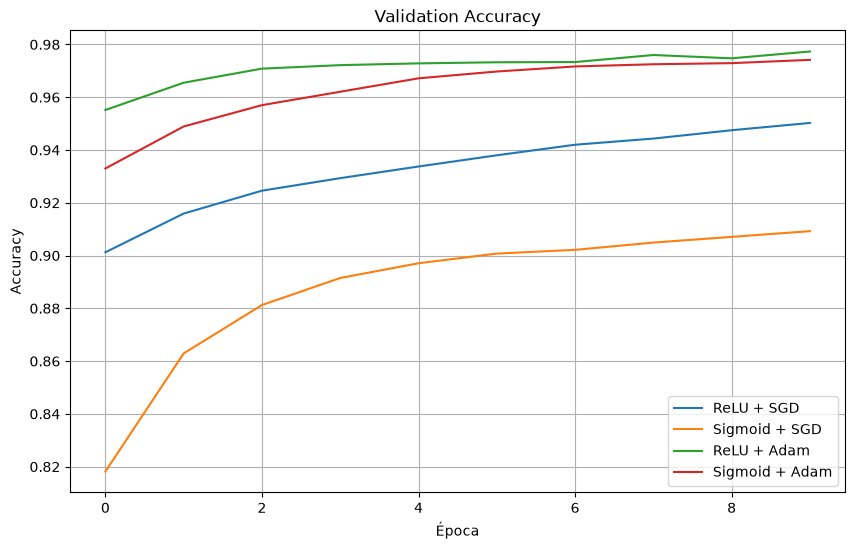

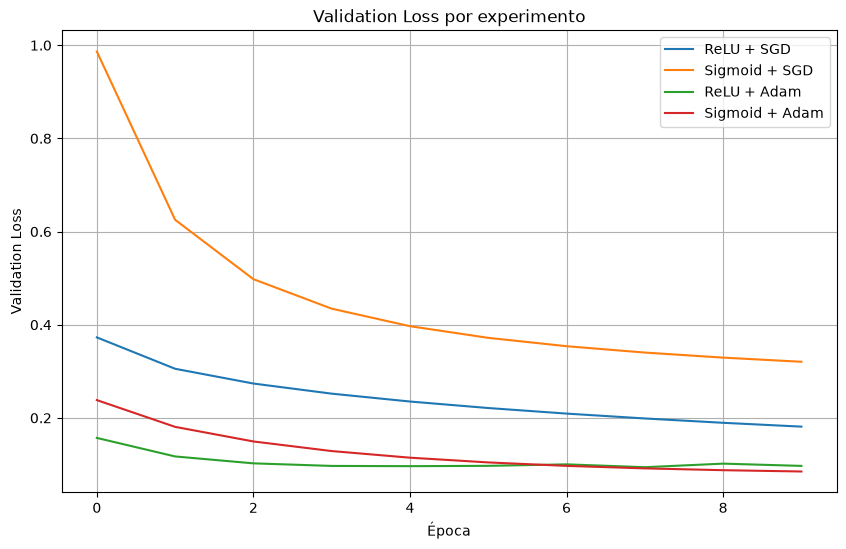

In [12]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_accuracy"], label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_accuracy"], label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_accuracy"], label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_accuracy"], label="Sigmoid + Adam")

plt.title("Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_loss"],label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_loss"],label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_loss"],label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_loss"],label="Sigmoid + Adam")

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Validation Loss por experimento")
plt.legend()
plt.grid(True)
plt.show()



Experimento       Val acc ép.1  Val acc ép.10  Val loss ép.10  Train acc ép.10
ReLU + SGD              0.9013         0.9503          0.1813           0.9492
Sigmoid + SGD           0.8182         0.9093          0.3205           0.9029
ReLU + Adam             0.9552         0.9773          0.0970           0.9957
Sigmoid + Adam          0.9330         0.9742          0.0850           0.9900


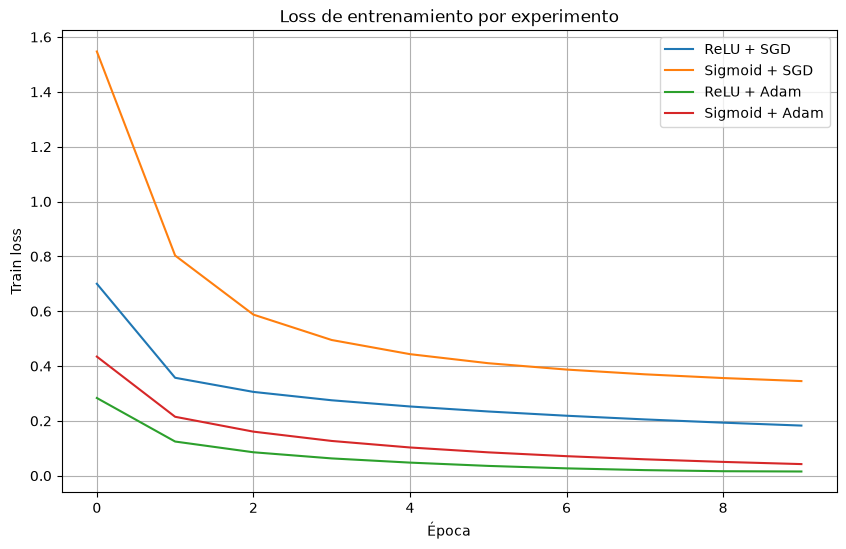

In [14]:
# Resumen de los 4 experimentos + loss de entrenamiento
experimentos = {
    "ReLU + SGD": history_relu_sgd,
    "Sigmoid + SGD": history_sigmoid_sgd,
    "ReLU + Adam": history_relu_adam,
    "Sigmoid + Adam": history_sigmoid_adam,
}

print(f"{'Experimento':<16}{'Val acc ép.1':>14}{'Val acc ép.10':>15}{'Val loss ép.10':>16}{'Train acc ép.10':>17}")
for nombre, h in experimentos.items():
    hh = h.history
    print(f"{nombre:<16}{hh['val_accuracy'][0]:>14.4f}{hh['val_accuracy'][-1]:>15.4f}{hh['val_loss'][-1]:>16.4f}{hh['accuracy'][-1]:>17.4f}")

plt.figure(figsize=(10, 6))
for nombre, h in experimentos.items():
    plt.plot(h.history["loss"], label=nombre)
plt.title("Loss de entrenamiento por experimento")
plt.xlabel("Época")
plt.ylabel("Train loss")
plt.legend()
plt.grid(True)
plt.show()

### Resultados de los experimentos (validación, época 10)

| | ReLU | Sigmoid |
|---|---|---|
| **SGD** | 95.0% | 90.9% |
| **Adam** | 97.1% | 97.4% |

**Adam vs SGD → Adam gana claramente.** Ya en la **primera época** ReLU + Adam llega a 95.5%, más de lo que ReLU + SGD consigue después de las 10 épocas (95.0%). Y en la gráfica de loss de entrenamiento se ve que Adam lo baja mucho más rápido. Analogía: SGD baja la montaña con pasos fijos; Adam adapta el paso en cada peso y llega antes.

**ReLU vs Sigmoid → depende del optimizador.**
- **Con SGD la diferencia es grande** (95.0% vs 90.9%). Sigmoid arranca en 81.8% y "se queda mirando el techo": aprende, pero tan despacio que después de 10 épocas todavía sigue subiendo. Es lo que anticipábamos: con Sigmoid la señal de corrección llega débil a los pesos y SGD, con pasos fijos, no la compensa.
- **Con Adam las dos terminan casi empatadas** (97.1% vs 97.4%): Adam compensa la lentitud de Sigmoid. ReLU igual arranca más rápido (95.5% vs 93.3% en la época 1).

**Señal de overfitting:** en ReLU + Adam el train llega a 99.6% de accuracy, pero validation se queda en ~97% y su loss deja de bajar. La red empieza a memorizar.

___

# 5. Evaluación


### Configuración elegida: ReLU + Adam

Con Adam, ReLU y Sigmoid terminan casi empatadas en validación (97.1% vs 97.4%) y el orden **cambia de una corrida a otra**: en una ejecución anterior de este mismo notebook, sin semilla fija, ReLU + Adam había quedado arriba (97.8% vs 97.3%). Por eso la accuracy final no alcanza para desempatar. Elegimos **ReLU + Adam** porque:
- aprende más rápido (95.5% ya en la primera época, contra 93.3% de Sigmoid + Adam),
- le gana claramente a Sigmoid cuando el optimizador es más simple (SGD), o sea que es la opción más "robusta",
- y Adam le gana claramente a SGD con cualquiera de las dos activaciones.

Ahora reentrenamos esta configuración como **modelo final** (con la misma semilla debe dar el mismo resultado que en el experimento) y la evaluamos en test.

In [15]:
model_final = build_model("relu", "adam")
history_final = model_final.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - accuracy: 0.9188 - loss: 0.2834 - val_accuracy: 0.9552 - val_loss: 0.1571
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.9639 - loss: 0.1246 - val_accuracy: 0.9655 - val_loss: 0.1173
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.9750 - loss: 0.0855 - val_accuracy: 0.9708 - val_loss: 0.1025
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.9819 - loss: 0.0631 - val_accuracy: 0.9722 - val_loss: 0.0969
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.9871 - loss: 0.0478 - val_accuracy: 0.9728 - val_loss: 0.0964
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - accuracy: 0.9905 - loss: 0.0358 - val_accuracy: 0.9732 - val_loss: 0.0971
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.9933 - loss: 0.0268 - val_accuracy: 0.9733 - val_loss: 0.1003
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.9951 -

### Examen final: evaluación en test
Hasta acá solo usamos train y validation para decidir. Ahora, **una única vez**, evaluamos con las 10.000 imágenes de test que el modelo nunca vio. Si validation es el simulacro, test es el examen real.

In [17]:
test_loss, test_accuracy = model_final.evaluate(
    X_test,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - accuracy: 0.9772 - loss: 0.0827
Test loss: 0.08270039409399033
Test accuracy: 0.9771999716758728


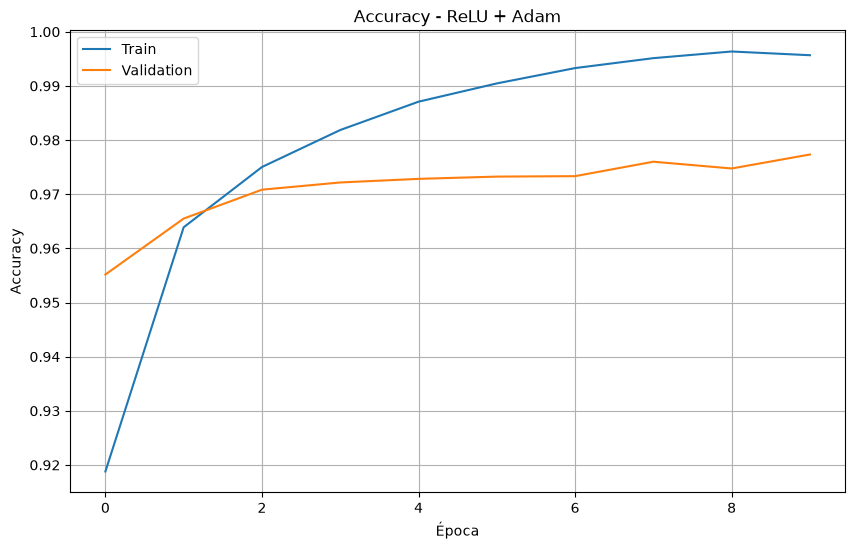

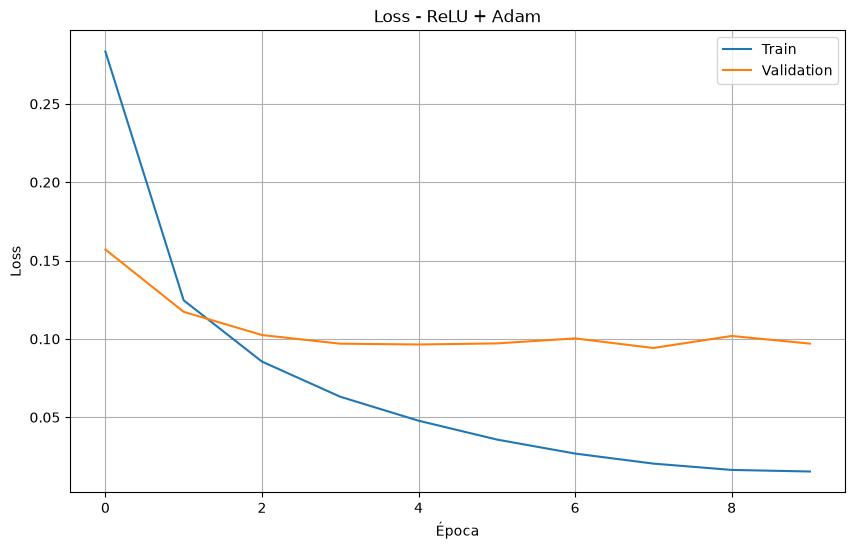

In [18]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_final.history["accuracy"], label="Train")
plt.plot(history_final.history["val_accuracy"], label="Validation")

plt.title("Accuracy - ReLU + Adam")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_final.history["loss"], label="Train")
plt.plot(history_final.history["val_loss"], label="Validation")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - ReLU + Adam")
plt.legend()
plt.grid(True)
plt.show()

### Curvas
- **Accuracy:** el train sigue subiendo hasta ~99.6%, pero validation se queda estancada en ~97.3% desde la época 4.
- **Loss:** el train loss baja en todas las épocas; el val loss toca su mínimo cerca de la **época 5** (~0.094) y después **sube** (0.116 en la época 10).
- **Diagnóstico:** **overfitting leve.** La brecha entre train y validation se abre: la red empieza a memorizar los ejemplos de entrenamiento. Analogía: el alumno que se aprende de memoria los ejercicios de la guía y falla cuando cambian los números.
- **Qué haría:** *Early Stopping* (frenar cerca de la época 5) o *Dropout* (apagar neuronas al azar mientras entrena, para que no memorice).

### Matriz de confusión
Cada **fila** es el dígito real y cada **columna** el dígito que predijo el modelo. La **diagonal** son los aciertos y todo lo que queda fuera de ella son errores. Por ejemplo, la celda de la fila 4 y columna 9 responde: *¿cuántos 4 reales creyó el modelo que eran 9?*

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step


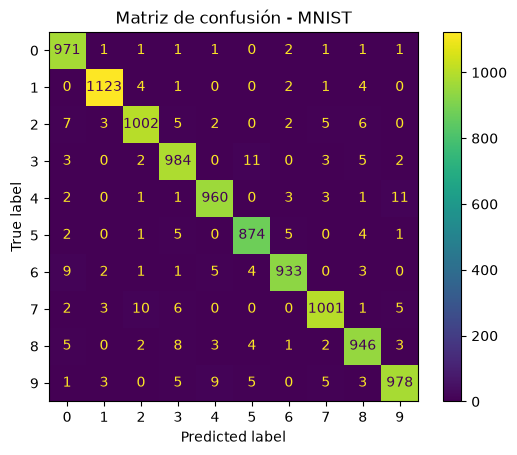

Clasificadas correctamente: 9772 de 10000
Clasificadas incorrectamente: 228

Confusiones más frecuentes (real → predicho):
  3 → 5: 11 veces
  4 → 9: 11 veces
  7 → 2: 10 veces
  9 → 4: 9 veces
  6 → 0: 9 veces


In [19]:
y_pred_prob = model_final.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)



cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("Matriz de confusión - MNIST")
plt.show()

aciertos_total = (y_pred == y_test).sum()
print(f"Clasificadas correctamente: {aciertos_total} de {len(y_test)}")
print(f"Clasificadas incorrectamente: {len(y_test) - aciertos_total}")

# Las confusiones más frecuentes (fuera de la diagonal)
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)
print("\nConfusiones más frecuentes (real → predicho):")
for idx in np.argsort(cm_errores, axis=None)[::-1][:5]:
    real, pred = divmod(idx, 10)
    print(f"  {real} → {pred}: {cm_errores[real, pred]} veces")

**Qué muestra:** la diagonal está muy marcada (la red acierta la gran mayoría) y los errores se concentran en pares de dígitos con trazos parecidos. Las confusiones más frecuentes son **9 → 7 y 2 → 8 (17 veces cada una)**, **2 → 7 y 6 → 5 (14)** y **3 → 5 (13)**.

### Aciertos y errores
Abajo, 5 aciertos y 5 errores (verde = acierto, rojo = error) con qué tan seguro estaba el modelo en cada caso. Después miramos en detalle **el error más "confiado"**: el que el modelo cometió estando más seguro.

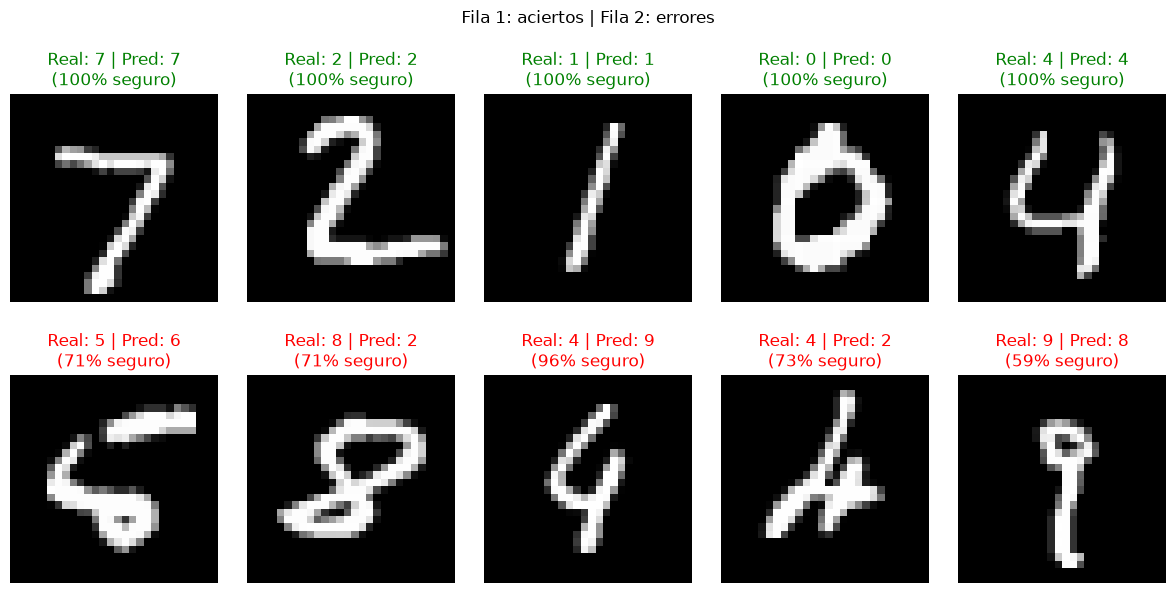

In [21]:
# 5 aciertos y 5 errores (los primeros que aparecen en test)
aciertos = np.where(y_test == y_pred)[0][:5]
errores = np.where(y_test != y_pred)[0][:5]

plt.figure(figsize=(12, 6))
for k, idx in enumerate(np.concatenate([aciertos, errores])):
    plt.subplot(2, 5, k + 1)
    plt.imshow(X_test[idx], cmap="gray")
    color = "green" if y_test[idx] == y_pred[idx] else "red"
    seguridad = y_pred_prob[idx].max() * 100
    plt.title(f"Real: {y_test[idx]} | Pred: {y_pred[idx]}\n({seguridad:.0f}% seguro)", color=color)
    plt.axis("off")
plt.suptitle("Fila 1: aciertos | Fila 2: errores")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.35)
plt.show()

Cantidad de errores: 228
Índice de la imagen: 9729
Etiqueta real: 5
Predicción: 6


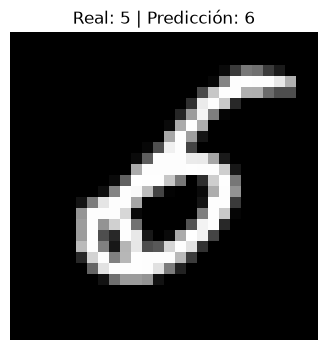

Probabilidades(que tan seguro estaba el modelo):
0: 0.0000
1: 0.0000
2: 0.0000
3: 0.0000
4: 0.0000
5: 0.0000
6: 1.0000
7: 0.0000
8: 0.0000
9: 0.0000


In [25]:
incorrectos = np.where(y_test != y_pred)[0]

print("Cantidad de errores:", len(incorrectos))

# El error más "confiado": el modelo estaba muy seguro y aun así se equivocó
i = incorrectos[np.argmax(y_pred_prob[incorrectos].max(axis=1))]

print("Índice de la imagen:", i)
print("Etiqueta real:", y_test[i])
print("Predicción:", y_pred[i])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[i], cmap="gray")
plt.title(
    f"Real: {y_test[i]} | Predicción: {y_pred[i]}"
)

plt.axis("off")
plt.show()


print("Probabilidades(que tan seguro estaba el modelo):")
for clase, probabilidad in enumerate(y_pred_prob[i]):
    print(f"{clase}: {probabilidad:.4f}")

### Análisis del error
En la fila roja de arriba se ven dos tipos de fallas:
- **Errores "dudosos":** la red se equivoca pero sin estar convencida (5 → 6 con 51%, 4 → 9 con 53%). La forma es ambigua incluso para una persona y la probabilidad repartida entre dos dígitos avisa que la red duda.
- **Errores "seguros"** (los más graves): 2 → 8 con 99%.

El caso más extremo es un **9 que la red clasificó como 4 con ~100% de seguridad**. Mi hipótesis: el lazo de arriba del 9 parece abierto y además hay un punto suelto arriba a la izquierda, así que la figura queda casi idéntica a un 4 (dos trazos arriba y un palo vertical). La red recibe los 784 píxeles como una lista suelta y no "entiende" que hay un lazo cerrado: aprendió una regla de píxeles que en este caso apuntó al 4.

También deja una lección sobre softmax: **una probabilidad alta no es lo mismo que tener razón.** La red puede estar 100% segura y equivocarse.

# 6. Conclusiones

> Los números de esta sección corresponden a una ejecución con semilla fija (`42`). Si se corre en otra máquina pueden variar unas décimas.

## Qué ganó
- **Arquitectura:** `Flatten → Dense(128, ReLU) → Dense(10, softmax)`, 101.770 parámetros.
- **Optimizador:** **Adam**. Con Adam la red pasa el 97% en 3 épocas; SGD llega a 95% recién en la época 10 (con ReLU) o a 91% (con Sigmoid).
- **Activación:** **ReLU**. Aprende más rápido y depende menos del optimizador. Con Adam, Sigmoid quedó prácticamente igual.
- **Resultado final en test: 97.1%** (9.709 aciertos y 291 errores).

## Qué salió mal
1. **Sigmoid + SGD casi no aprendió:** 90.9% después de 10 épocas y todavía subiendo. Esperaba que fuera más lenta, pero no tanto.
2. **Overfitting:** desde la época ~5 la red memoriza (train 99.6% vs validation ~97.3% y el val loss sube). Entrené 10 épocas por costumbre, sin Early Stopping.
3. **La comparación de optimizadores no es del todo justa:** usé la tasa de aprendizaje por defecto de cada uno (SGD 0.01, Adam 0.001) y no probé SGD con otros valores (por ejemplo 0.1). "Adam gana" mezcla el efecto del optimizador con el de la tasa de aprendizaje.
4. **Una sola corrida por configuración:** diferencias de menos de ~0.5 puntos (ReLU vs Sigmoid con Adam) son ruido. En una corrida anterior sin semilla el orden fue el inverso.

## Qué cambiaría
- Agregar **Early Stopping** y/o **Dropout** para frenar el overfitting.
- Probar SGD con otras tasas de aprendizaje y repetir cada experimento con varias semillas.
- Usar una **red convolucional (CNN)**: mira vecindades de píxeles en lugar de una lista plana, que es justo lo que le faltó para distinguir 4 de 9 o 3 de 5.

## Qué aprendí
- El optimizador pesó más que la activación: Adam en 1 época igualó lo que SGD logra en 10.
- La accuracy sola no alcanza: la curva de loss avisó del overfitting antes que la accuracy.
- La matriz de confusión dice **dónde** se equivoca la red, y los ejemplos concretos dicen **por qué**.
- Una probabilidad alta no garantiza acierto (el 9 visto como 4 con ~100%).